# Zapbench Model Evaluation

Load a trained model and evaluate using the same code as training.

In [2]:
# configuration
RUN_DIR = "/groups/saalfeld/home/kumarv4/repos/NeuralGraph/runs/zb_tiny64_20260210_190c953/f2bd5c"
MAX_ROLLOUT_FRAMES = 32  # limit evaluation to first N frames (None for full)

In [3]:
%matplotlib inline
import queue
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml

# add parent to path for imports
sys.path.insert(0, str(Path.cwd().parent.parent))

from LatentEvolution.zapbench_train import (
    ZapbenchConfig,
    load_all_data,
    run_validation_cpu,
    print_results_table,
    plot_per_frame_metrics,
    ValidationResult,
)
from LatentEvolution.zapbench_eed import EEDModel
from LatentEvolution.zapbench_config import ModelConfig

In [8]:
device = torch.device("cuda:1")

In [9]:
# load config
run_dir = Path(RUN_DIR)
config_path = run_dir / "config.yaml"
model_path = run_dir / "model_final.pt"

with open(config_path) as f:
    config_dict = yaml.safe_load(f)

cfg = ZapbenchConfig(**config_dict)
print(f"loaded config from {config_path}")
print(f"  latent_dims: {cfg.model.latent_dims}")
print(f"  fitting_window: {cfg.train.fitting_window} bins = {cfg.train.fitting_window * 40 / 1000:.1f}s")

loaded config from /groups/saalfeld/home/kumarv4/repos/NeuralGraph/runs/zb_tiny64_20260210_190c953/f2bd5c/config.yaml
  latent_dims: 64
  fitting_window: 100 bins = 4.0s


In [10]:
# load val/test data only (skip train to save memory)
_, val_data, test_data = load_all_data(
    cfg.data.traces_path, cfg.data.ephys_path, cfg.data.bin_size_ms,
    cfg.split, cfg.train.fitting_window, device,
    skip_train=True,
)

num_neurons = val_data[0].num_neurons
print(f"\nnum_neurons: {num_neurons}")
print(f"val conditions: {[c.name for c in val_data]}")
print(f"test conditions: {[c.name for c in test_data]}")

10:29:47   loading gain...
10:29:56     val: T=1482, frames=65, valid=[20, 1363)
10:30:01     test: T=2945, frames=129, valid=[20, 2826)
10:30:01   loading dots...
10:30:07     val: T=4042, frames=177, valid=[20, 3923)
10:30:08     test: T=8086, frames=354, valid=[20, 7967)
10:30:09   loading flash...
10:30:11     val: T=1483, frames=65, valid=[20, 1363)
10:30:11     test: T=2991, frames=131, valid=[20, 2872)
10:30:11   loading taxis...
10:30:16     test: T=14965, frames=655, valid=[21, 14846)
10:30:16   loading turning...
10:30:20     val: T=2991, frames=131, valid=[20, 2872)
10:30:22     test: T=5984, frames=262, valid=[20, 5864)
10:30:22   loading position...
10:30:24     val: T=1346, frames=59, valid=[21, 1227)
10:30:24     test: T=2693, frames=118, valid=[20, 2574)
10:30:24   loading open_loop...
10:30:27     val: T=2237, frames=98, valid=[20, 2117)
10:30:28     test: T=4499, frames=197, valid=[20, 4380)
10:30:28   loading rotation...
10:30:31     val: T=1483, frames=65, valid=[20


num_neurons: 71721
val conditions: ['gain', 'dots', 'flash', 'turning', 'position', 'open_loop', 'rotation', 'dark']
test conditions: ['gain', 'dots', 'flash', 'taxis', 'turning', 'position', 'open_loop', 'rotation', 'dark']


In [11]:
# create model and load weights
model_cfg = ModelConfig(
    num_neurons=num_neurons,
    latent_dims=cfg.model.latent_dims,
    encoder_decoder=cfg.model.encoder_decoder,
    evolver=cfg.model.evolver,
)

model = EEDModel(model_cfg)
model.load_state_dict(torch.load(model_path, map_location="cpu", weights_only=True))
model.eval()
print(f"loaded model from {model_path}")
print(f"  parameters: {sum(p.numel() for p in model.parameters()):,}")

loaded model from /groups/saalfeld/home/kumarv4/repos/NeuralGraph/runs/zb_tiny64_20260210_190c953/f2bd5c/model_final.pt
  parameters: 23,076,393


In [12]:
def run_evaluation(model_cfg, state_dict, conditions, max_rollout_frames=None):
    """wrapper to call run_validation_cpu synchronously."""
    result_queue = queue.Queue()
    run_validation_cpu(
        model_cfg=model_cfg,
        state_dict=state_dict,
        val_conditions=conditions,
        result_queue=result_queue,
        epoch=0,
        max_rollout_frames=max_rollout_frames,
    )
    return result_queue.get()

# get state dict on CPU
state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}

In [14]:
def print_results(result: ValidationResult, name: str, include_baseline: bool = True):
    """print results tables (notebook-friendly version of print_results_table)."""
    key_steps = [1, 2, 4, 8, 16, 32]

    def make_table(per_condition: dict[str, np.ndarray], metric_name: str):
        header = f"{'condition':<12}"
        for step in key_steps:
            header += f" {f'step{step}':>8}"
        print(header)
        print("-" * len(header))

        means_per_step = {step: [] for step in key_steps}
        for cond_name in sorted(per_condition.keys()):
            values = per_condition[cond_name]
            row = f"{cond_name:<12}"
            for step in key_steps:
                idx = step - 1
                if idx < len(values):
                    val = values[idx]
                    row += f" {val:>8.4f}"
                    means_per_step[step].append(val)
                else:
                    row += f" {'n/a':>8}"
            print(row)

        print("-" * len(header))
        mean_row = f"{'MEAN':<12}"
        for step in key_steps:
            if means_per_step[step]:
                mean_row += f" {np.mean(means_per_step[step]):>8.4f}"
            else:
                mean_row += f" {'n/a':>8}"
        print(mean_row)

    # print(f"\n{name} - MSE by Frame:")
    # make_table(result.per_condition_mse, "MSE")

    # if include_baseline:
    #     print(f"\n{name} - Baseline MSE by Frame:")
    #     make_table(result.baseline_mse, "Baseline MSE")

    print(f"\n{name} - MAE by Frame:")
    make_table(result.per_condition_mae, "MAE")

    if include_baseline:
        print(f"\n{name} - Baseline MAE by Frame:")
        make_table(result.baseline_mae, "Baseline MAE")

In [15]:
def plot_results(result: ValidationResult, title: str):
    """plot MSE and MAE vs frame using the training code."""
    figures = plot_per_frame_metrics(result, cfg.train.fitting_window, prefix=title)
    for fig in figures.values():
        plt.figure(fig.number)
        plt.show()

## Validation Set

In [17]:
val_result = run_evaluation(model_cfg, state_dict, val_data, MAX_ROLLOUT_FRAMES)
print_results(val_result, "Validation")


Validation - MAE by Frame:
condition       step1    step2    step4    step8   step16   step32
------------------------------------------------------------------
dark           0.0233   0.0243   0.0244   0.0280   0.0374   0.0798
dots           0.0237   0.0237   0.0239   0.0244   0.0265   0.0344
flash          0.0255   0.0266   0.0264   0.0298   0.0366   0.0422
gain           0.0243   0.0247   0.0278   0.0329   0.0359   0.0357
open_loop      0.0231   0.0232   0.0235   0.0242   0.0293   0.0485
position       0.0233   0.0235   0.0227   0.0230   0.0282   0.0422
rotation       0.0270   0.0278   0.0301   0.0528   0.0563   0.0751
turning        0.0274   0.0275   0.0283   0.0345   0.0300   0.0325
------------------------------------------------------------------
MEAN           0.0247   0.0252   0.0259   0.0312   0.0350   0.0488

Validation - Baseline MAE by Frame:
condition       step1    step2    step4    step8   step16   step32
----------------------------------------------------------------

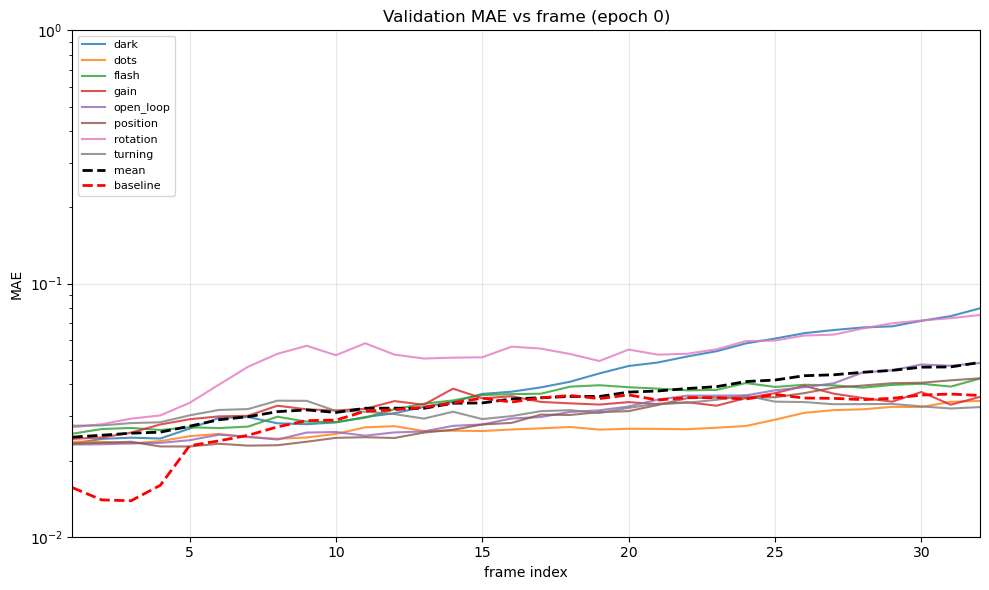

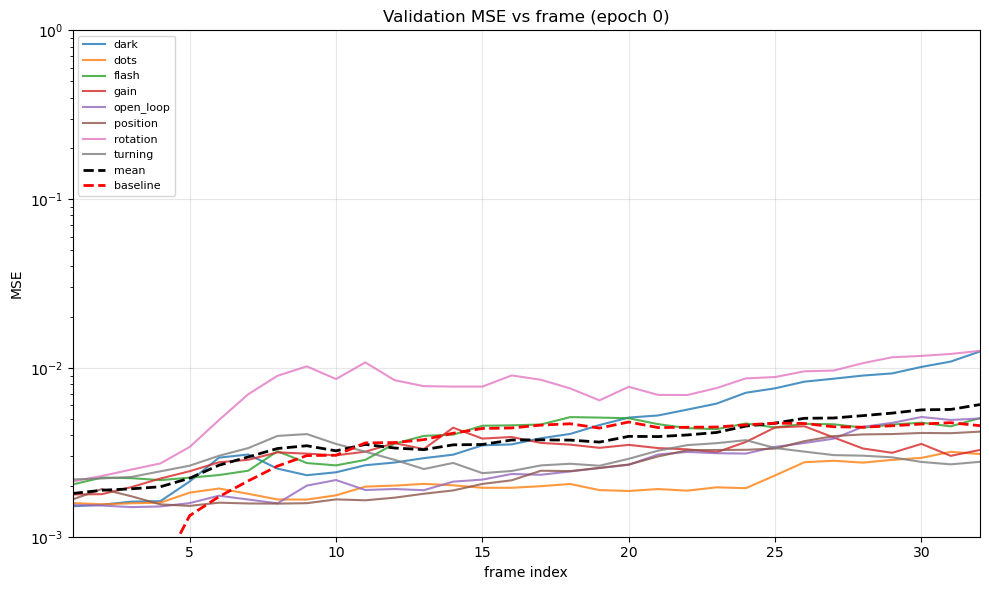

<Figure size 640x480 with 0 Axes>

In [21]:
plot_results(val_result, "Validation")

## Test Set

In [22]:
test_result = run_evaluation(model_cfg, state_dict, test_data, MAX_ROLLOUT_FRAMES)
print_results(test_result, "Test")


Test - MAE by Frame:
condition       step1    step2    step4    step8   step16   step32
------------------------------------------------------------------
dark           0.0249   0.0248   0.0254   0.0282   0.0298   0.0590
dots           0.0239   0.0245   0.0245   0.0269   0.0275   0.0403
flash          0.0260   0.0259   0.0287   0.0302   0.0362   0.0458
gain           0.0258   0.0268   0.0302   0.0321   0.0425   0.0610
open_loop      0.0248   0.0251   0.0255   0.0270   0.0265   0.0367
position       0.0228   0.0237   0.0246   0.0287   0.0339   0.0408
rotation       0.0266   0.0267   0.0291   0.0315   0.0372   0.0630
taxis          0.0258   0.0258   0.0275   0.0317   0.0398   0.0371
turning        0.0300   0.0297   0.0296   0.0305   0.0338   0.0555
------------------------------------------------------------------
MEAN           0.0256   0.0259   0.0272   0.0296   0.0341   0.0488

Test - Baseline MAE by Frame:
condition       step1    step2    step4    step8   step16   step32
---------

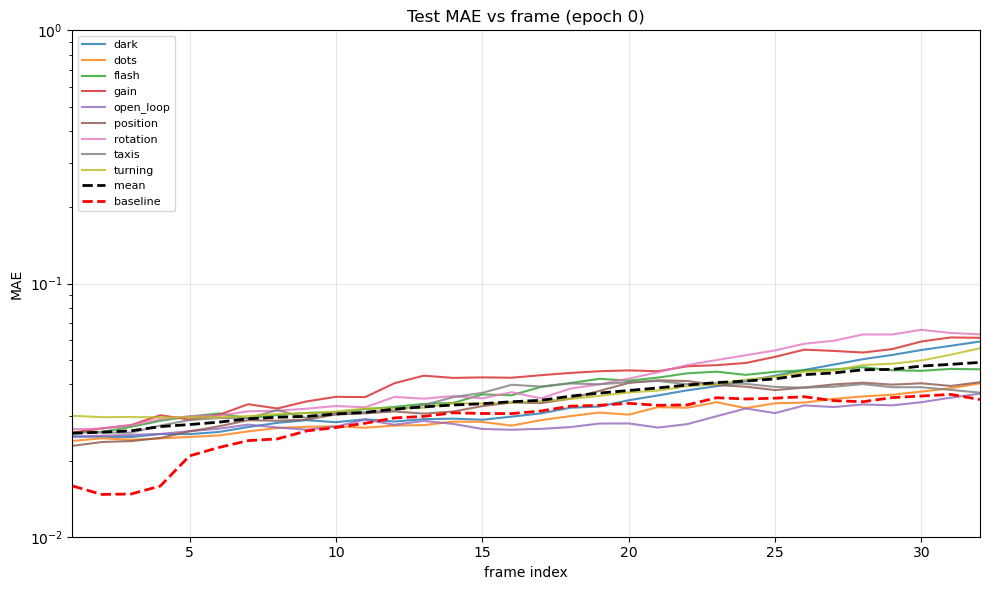

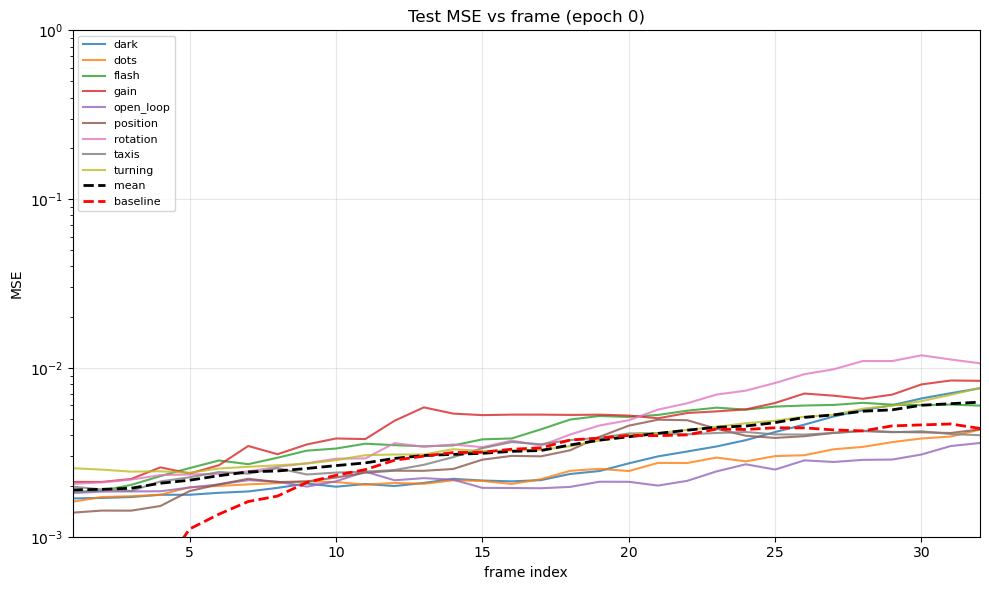

<Figure size 640x480 with 0 Axes>

In [23]:
plot_results(test_result, "Test")